<h1>24 - Apprentissage non supervisé avec Python</h1>

Lien Vidéo tuto: <a href="https://www.youtube.com/watch?v=w_bLGK4Pteo&list=PLO_fdPEVlfKqMDNmCFzQISI2H_nJcEDJq&index=22">TAPPRENTISSAGE NON-SUPERVISÉ avec Python (24/30)</a> (durée : 41 min)

Lien Notebook : <a href="https://github.com/MachineLearnia/Python-Machine-Learning/blob/master/24%20-%20Sklearn%20%3A%20Apprentissage%20Non-supervisé.ipynb">24/30 Apprentissage Non-Supervisé.ipynb</a>

L'apprentissage non supervisé est la seconde approche très connue du Machine et du Deep Learning. On va voir ci-dessous quelles sont les 3 applications les plus importantes qui sont : 
- le clustering
- la déterction d'anomalie 
- la réduction de dimension

Pour commencer, il faut comprendre ce qu'est l'apprentissage non-supervisé. Il s'agit d'une méthode d'apprentissage dans laquelle, au lieu de montrer à la machine des exemples $(X, y)$ de ce qu'elle doit apprendre, on lui founit uniquement des données $X$ et on lui demande d'analyser la structure de ces données pour apprendre, elle-même, à réaliser certaines taches. 

Par exemple, le machine peut apprendre à classer des données en se basant uniquement sur leur ressemblance. On parle de CLUSTERING. Cette technique peut permettre de faire beaucoup de choses, comme classer des documents, des photos, des Tweets, segmenter la clientèle d'une entreprisen etc ... Ici, on va voir comment réaliser ce type de taches avec l'algorithme `K-Means Clustering`.

Une autre tache que la machine peut faire grâce à l'apprentissage non supervisé est, la détection d'anomalie. Pour cela, la machine analyse la structure de nos données, et parvient à trouver les échantillons dont les caractéristiques sont très éloignées de celles des autres échantillons. Et ça, ça nous permet de développer :
- des systèmes de sécurité 
- des systèmes de détection de fraude bancaire (hacking)
- des systèmes de détection de défaillance sur des pièces dans une usine 
Ici, on va voir comment réaliser ce type de tâche à partir du modèle `Isolation Forest`

Enfin, une technique très populaire de l'apprentissage non supervisé est la réduction de dimensionnalité. C'est-à-dire, qu'en analysant la structure de nos données, ma machine apprend comment simplifier cette structure tout en conservant les principales informations. Par exemple, c'est comme si la machine apprend la structure d'un dessin et apprend à redessiner ce dessins de manière plus simple tout en conservant les principaux éléments. Sur le plan mathématique, la machine apprend à projeter nos données dans des espaces de plus petite dimension. Un des alhorithmes qui permet de faire cela est l'agorythme `PCA` (Analyse en composante principale). À noter que les applications de cet algorithme sont absolument géniales. En effet, on peut non seulement simplifier la complexité superflue que peut avoir un dataset, ce qui facilite alors beaucoup l'apprentissage de la machine pour des problèmes de régression ou de classification, mais on peut également visualiser en 2D ou 3D des espaces qui vont bien au delà de notre imagination.

À noter qu'ici, on va apprendre à implémenter ces 3 algorithmes en utilisant scikit-learn. 


<h2>Setup</h2>

In [13]:
# Standard libraries
import numpy as np
from sklearn.datasets import make_blobs

# Data libraries
from sklearn.datasets import load_digits

# Visualization libraries
import matplotlib.pyplot as plt

# ML libraries
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA

<h2>Clustering</h2>

On va commencer avec le Clustering. Le principe est de laisser la machine apprendre à classer nos données en fonction de leur ressemblance. Pour cela, un des algorithme les plus populaire en ce moment est le `K-Means Clustering`.

Supposons qu'on ait un ensemble de données et qu'on souhaite les regrouper en 3 clusters. Pour cela, on va commencer à placer 3 points appelés centroïdes, au hasard parmi nos données. Ensuite, on affecte chacun de nos points de donnés au centroïde le plus proche. Ce qui nous donne 3 clusters. Puis, on déplace chaque centroïde au milieu de son cluster. Ensuite, on recommance, on affecte à nouveau chaque point de notre dataset au centreoïde le plus proche, et on déplace à nouveau chaque centroïde au centre de son cluster. On va procéder ainsi, de manière itérative, jusqu'à ce que les centroïdes convergent vers une position d'équilibre. 

On l'aura compris, l'algorithme `K-Means Clustering` est en réalité un algorithme itératif qui fonctionne en deux étapes :
- 1er étape : on affecte les points des datasets aux centreoïdes les plus proches 
- 2nd étape : on calcule la moyenne de chaque cluster et on y déplace le centroïde

Attention, c'est possible qu'à cause de la localisation initiale de nos centroïdes, ces derniers convergent vers de mauvaises positions. Heureusement, il existe une solution pour éviter ça. Pour cela, on va exécuter l'algorithme de `K-Mean Clustering` plusieurs fois d'à filé, en modifiant à chaque fois la position initiale de nos centroïdes. Pour chaque résultat, on mesure la distance entre les points de chaque cluster et leur centroïde, et on retient la solution pour laquelle la somme de ces distances est la plus petite. 

En résumé, l'algorithme de `K-Means Clustering` cherche en faite à minimiser une fonction coût, appelée `inertia`, qui représente la distance entre les points d'un cluster ($x_i$) et le centre de ce dernier ($\mu _j$) : $\sum^n_{i=0}min(||x_i - \mu _j ||^2)$. 
Et cela, ressemble à peu de choses prêt, à la variance de nos cluster. On peut donc dire que cet algo cherche à minimiser la variance des clusters.

<h3><u>Implémenter un modèle KMeans Clustering</u></h3>

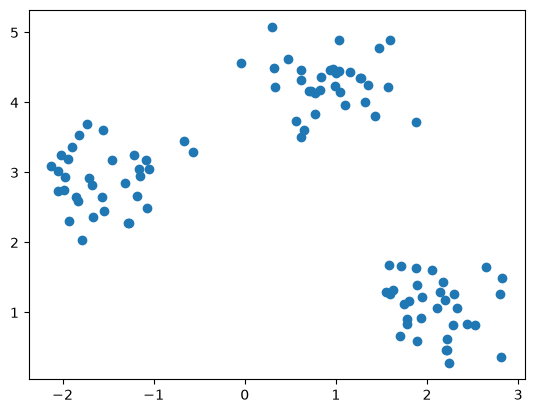

In [17]:
# Generate synthetic data
X, y = make_blobs(n_samples=100, centers=3, cluster_std=0.4, random_state=0)

# Display the generated data
plt.scatter(X[:, 0], X[:, 1])

In [18]:
# Instantiate the model 
model = KMeans(n_clusters=3)

Si on avait voulu, on aurait également pu :
- définir le nombre d'initialisation qu'on aurait voulu pour notre algorithme avec le paramètre `n_init`. C'est-à-dire, le nombre de fois que l'amgorithme sera exécuté. Par défaut, ce paramètre est fixé à 10
- définir le nombre d'itération max avec le paramètre `max_iter`. Par défaut, cette valeur doit être fixée autour de 200 ou 300.
- définir quelle stratégie d'initialisaton on va utiliser, avec le paramètre `init`. Par défaut, c'est la méthode `K-Means++` qui est utilisée. Cette technique permet de placer nos centroïdes sur des points trés éloignés de notre dataset, ceci dans le but d'accélérer la convergence de nos centroïdes vers des positions d'équilibre. C'est déjà une très bonne technique d'initialisation donc Guillaume nous conseille de ne pas y toucher.

En définitive, quand on utilise le modèle KMeans, la seule chose qu'il reste à faire est d'indiquer le nombre de cluster qu'on chercher à obtenir en sortie.

Show to each cluster each data point belongs:
 [1 0 1 0 0 0 2 2 1 0 0 0 1 0 2 1 2 0 2 2 2 2 2 0 1 1 1 1 2 2 0 1 1 0 2 2 0
 1 1 2 2 1 1 0 0 0 1 1 2 2 2 1 0 1 2 2 1 1 0 1 1 2 2 2 2 1 0 2 1 0 2 0 0 1
 1 0 0 0 2 1 0 0 1 0 1 0 0 0 1 0 1 1 2 2 2 2 0 0 2 2]
Show to each cluster each data point belongs:
 [1 0 1 0 0 0 2 2 1 0 0 0 1 0 2 1 2 0 2 2 2 2 2 0 1 1 1 1 2 2 0 1 1 0 2 2 0
 1 1 2 2 1 1 0 0 0 1 1 2 2 2 1 0 1 2 2 1 1 0 1 1 2 2 2 2 1 0 2 1 0 2 0 0 1
 1 0 0 0 2 1 0 0 1 0 1 0 0 0 1 0 1 1 2 2 2 2 0 0 2 2]

Centroïds coodinates:
 [[ 0.92702654  4.27385438]
 [ 2.08889087  1.07930405]
 [-1.55022199  2.90542155]]


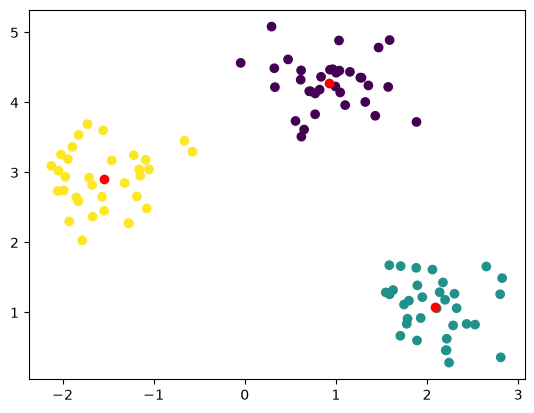

In [19]:

# Train de model using X data
model.fit(X)

# Display the clusters : 2 methods
print(f"Show to each cluster each data point belongs:\n {model.labels_}")
print(f"Show to each cluster each data point belongs:\n {model.predict(X)}") # Better to use it on new inputs

# Display the centroïds coordinates 
print(f"\nCentroïds coodinates:\n {model.cluster_centers_}")

# Build the graphic to show each cluster with its centroïd
# -- x----------------------x --
# Display the data with a specific color for each cluster
plt.scatter(X[:,0], X[:, 1], c=model.predict(X)) # With X[:,0] the x coordinate and X[:, 1] the y coordinate
# Add the centroïds on the graphic
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1], c='r')
# -- x----------------------x --


In [ ]:
# Display the model inertia
print(f"Model inertia: {model.inertia_}")


# Display the model scores, that is the inertia but negative
model.score(X)

Model inertia: 30.870531280140682


-30.870531280140675

Ainsi, l'inertia, c'est-à-dire la somme des distances entre les points d'un cluster et son centroïde. Ici elle est environ de 30.5, l'unité étant celle de nos données de notre dataset (cm, euro, litre, ...)

Note : 
Une autre chose sympas qu'on peut faire avec un modèle `K-Means Clustering` est de l'utiliser comme un transformer. En effet, il existe des méthodes telle que `.fit_transform()` qui retourne la distance entre chaque point d'un cluster et son centroïde. 

<h3><u>The Elbow Method</u></h3>

On a compris comment implémenter rapidement le modèle `K-Means Clustering`, mais comment être sûr qu'on a définit le bon nombre de cluster pour notre algorithme. Dans notre cas, visuellement c'était assez facile de déterminer combien de cluster on allait chercher à définir. Mais dans le cas où on se trouve en présence d'un dataset avec des centaines de dimensions, dans lequel, nos données sont un peu mélangées, ce n'est pas du tout évident. 

Pour cela, on peut avoir recour à la `Elbow Method` qui consiste à tracer l'évolution du coût de notre modèle en fonction du nombre de clusters, et de détecter dans ce graphique une zone de coude. C'est cette zone qui nous indique le nombre de clusters optimal. C'est-à-dire le nombre de clusters qui nous permet de réduire au maximum le coût de notre modèle, tout en conservant un nombre raisonnable de clusters.

In [22]:
# Instantiate an empty list to store the inertia values 
inertia = []

# Define a range for the cluster numbers
K_range = range(1, 20)

In [23]:
# Itératively train the KMeans Clustering model to get each inertia
for k in K_range:
    # Instantiate and train the model
    model = KMeans(n_clusters=k).fit(X)
    # Extract the inertia and add it to the list
    inertia.append(model.inertia_)

Text(0, 0.5, 'Model cost (Inertia)')

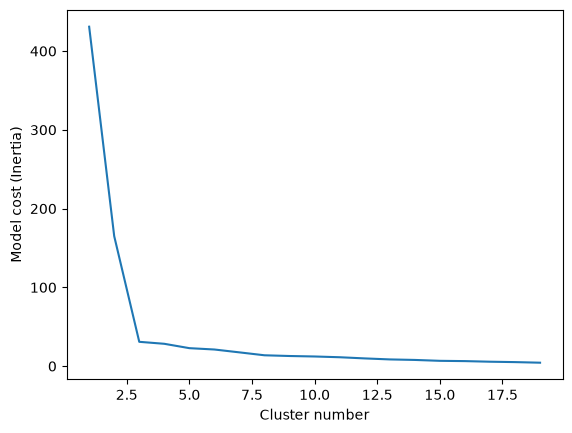

In [24]:
# Build a graph to display the inertia evolution in function of the number of cluster
plt.plot(K_range, inertia)
plt.xlabel("Cluster number")
plt.ylabel("Model cost (Inertia)")

En observant le graphique, on observe qu'il existe une zone de coude pour $K = 3$. Ce qui est parfaitement cohérent avec l'allure de nos données.

Dans `Scikit-Learn`, il existe de nombreux algorithmes de clustering en plus du `KMeans Clustering`. S'il fallait on retenir que quelques uns, on pourrait citer :
- `DBSAN` : pour "Densiy-based spatial clustering or application with noise" (`cluster.DBSCAN`)
- `AgglomerativeClustering` : hierarchical clustering (`cluster.AgglomerativeClustering`)
- `Spectral Clustering` : (`cluster.SpectralCoclustering`)

Les deux premiers sont très utiles quand on souhaite segmenter des données qui forment des clusters non-convexe ou anisotropes. Sur de tels cas de figures, ils donneront de meilleurs résultats que `KMeans Clustering`

<h2>Détection d'anomalie</h2>

Comme on a pu le voir au début de la vidéo, la détection d'anomalie requière des techniques d'apprentissage non-suprvisées, qui consiste à détecter dans notre dataset les échantillons dont les caractéristiques $X$ sont très éloignées de celles des autres échantillons. Pour cela, on peut par exemple calculer la moyenne et l'écart type de nos données, pour déterminer une fonction `densité de probabilité` et se servir de cette fonction pour calculer la probabilité d'existance d'un échantillon donné. Si cette probabilité est en dessous d'un certain seuil, alors l'échantillon est considéré comme anormal.

Cette technique fonctionne très bien, mais ici, on va présenter une méthode plus moderne et plus efficace pour faire ce genre de choses. Cette méthode, c'est l'algorithme `Isolation Forest`.

L'idée est la suivante: dans notre dataset, on va effectuer une série de split aléatoires, et on va compter le nombre de découpes qu'il faut effectuer pour réussir à isoler nos échantillons. Plus ce nombre est petit, et plus il y a de chances que cet échantillons soit en faite une anomalie. 

<u>Protocole</u>:

- Choisir un axe (x ou y) au hasard et tracer un trait orthogonal (perpendiculaire)
- se demander si on a isolé une donnée (oui / non)
    - oui : alors on a surrement une anomalie 
    - non : alors on choisit à nouveau une de nos deux variable (x u y) au hasard, et on trace un autre trait. On vérifie si on a pu isoler un nouvel échantillon (oui / non), etc 

On réalise ces opération de manière itératives jusqu'à ce qu'un échantillon finisse par être isolé.

De cette manière, en appliquant cet algorithme il est possible de détecter une anomalie en comptant le nombre de splits qu'on a réalisés jusqu'à pouvoir isoler cet échantillon. Ce qu'il faut comprendre, c'est que, plus ce nombre est petit, et plus la probabilé d'avoir effectivement isolé une anomalie est grande.

Bien sûr, il n'est pas impossible d'isolé un échantillon faisant parti de notre masse de données, avant de réussir à isoler notre anomalie. C'est très peu probable, mais c'est possible. Il existe alors une solution pour que la machine évite de considére cet échantillon là(celui faisant parti de l'ensemble de données), comme une anomalie. Cette solution consiste à demander à la machine de générer plusieurs estimateurs qui vont chacun effectuer une séquence de splits aléatoires. Ainsi, en considérant l'ensemble de leurs résutlats, on peut discalifier les quelques petites erreurs fait par certains estimateurs. En effet, les résutlats de la majorité vont l'emporter. Cette technique est uen technique d'ensembles. Pourquoi ? parce qu'on ne va pas utiliser UN, mais PLUSIEURS estimateurs, pour ensuite considére l'ensemble de leurs estimations.

L'algorithme `isolation forest` est donc ensemble de générateurs de type `arbre`. Et que les splits qu'on a réalisés, representent en faite les embranchements des différents arbres de notre forêt. 

Voyons maintenant comment faire ça avec Scikit-Learn. 

<h3><u>Isolation forest sur un dataset synthétique</u></h3>


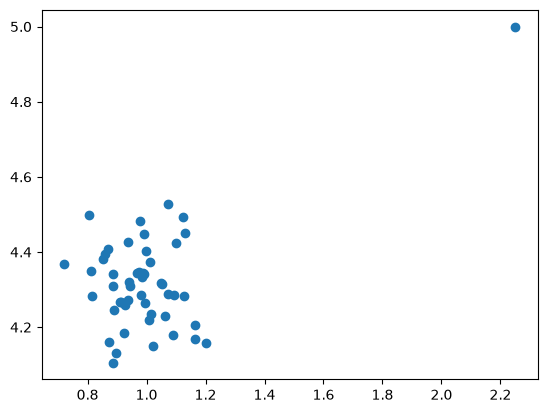

In [4]:
# Generate a bunch of synthetic data
X, y = make_blobs(n_samples=50, centers=1, cluster_std=0.1, random_state=0)

# Add an anomalie
X[-1, :] = np.array([2.25, 5])

# Display the data
plt.scatter(X[:, 0], X[:, 1])


Maintenant on va devoir instantier le modèle en spécifiant le taux de contamination. C'est-à-dire, qu'on va indiquer la proportion de déchet qu'on pense que notre dataset contient. Ici on va indiquer qu'on pense que 1% (0,01) de notre dataset n'est pas bon. Et le travail du modèle ça va être d'identifier les échantillons de manière à obtenir ce 1% de déchet. Il n'est pas nécessaire de spécifier d'autres paramètres pour faire fonctionner le modèle. 

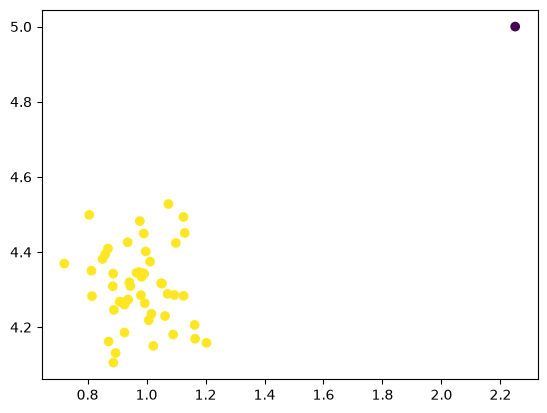

In [5]:
# Instantiate the model isolation forest
model = IsolationForest(contamination=0.01)

# Fit the model to the data
model.fit(X)

1 # Display the result
plt.scatter(X[:, 0], X[:, 1], c=model.predict(X))

Ici on a dont appliquer le modèle ajusté à nos données pour prédire avec `model.predict(X)` quel était notre anomalie. 

Cette technique peut être utilisée pour détecter tout type d'anomalie:
- fraudes bancaires
- défaillances techniques dans une usine 
- un comportement anormale sur une caméra de surveillance 
- ou simplement les outliers qu'il pourrait y avoir dans un dataset qu'on souhaite nettoyer 


<h3><u>Isolatio forest sur la détection des outliers</u> : digits outliers</h3>

On va essayer de trouver dans le dataser `digits` quels sont les chiffres les moins biens écrits en utilisant cette méthode `isolation forest`. C'est-à-dire, ceux qu'il est préférable d'éliminer avant de donner notre dataset à un modèle pour l'apprentissage d'une tâche de classification. 

Le dataset `digits` est un dataset qui contient 1797 échantillons. C'est à dire 1797 images de chiffres, allant de 0 à 9, et ces chiffres sont écrit sur des images qui font 64 pixels.

(1797, 64)


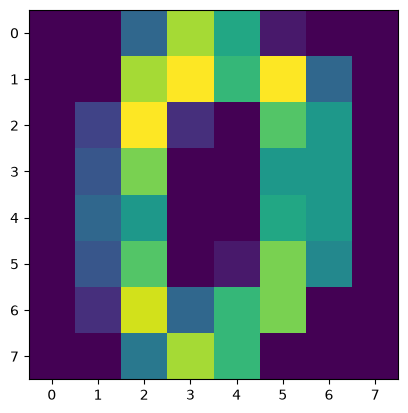

In [10]:
# Load the dataset
digits = load_digits()

# Extract images 
images = digits.images

# Extract data and targets
X = digits.data
y = digits.target

# Display the shape 
print(X.shape)

# Display the first digit
plt.imshow(images[0])

In [11]:
# Instantiate the model with a supposed contamination of 2%
model = IsolationForest(random_state=0, contamination=0.02)

# Fit the model to the data
model.fit(X)


,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",0
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...andom_state=0)


In [12]:
model.predict(X)

array([1, 1, 1, ..., 1, 1, 1], shape=(1797,))

Quand on utilise la méthode `predict`, on obtient en sortie une liste avec un label de classification : 
- +1 : valeur normale
- -1 : anomalie 

À noter qu'ici, on aura essentiellement des 1 car on a spécifié au modèle que le dataset contiendrait probablement 2% d'anomalies. Donc pour filtrer tout ça, on va simlpement spécifier qu'on souhaite retourner que les anomalies, lorsqu'on demande au modèle de prédire les valeurs anormales de notre dataset. Pour cela on va donc indiquer transformer ce tableau en valeurs booléennes via l'instruction `== -1`. Ce cette manière, on va obtenir un tableau de valeurs booléanne avec noté `False` pour les valeurs à 1 et `True` pour les valeurs à `-1`. 

Une fois qu'on a ce tableau booléen, on peut l'utiliser pour extraire uniquement les anomalies à partir des vairables `X`, `y`ou même `images`. C'est ce qu'on va faire ci-dessous pour n'afficher que les images "`anormales`"

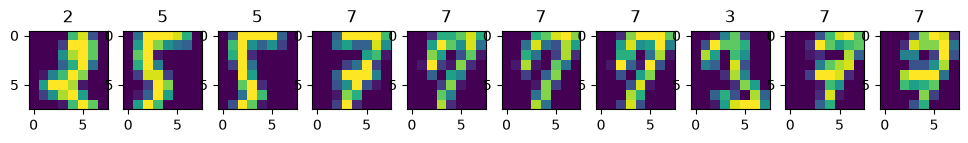

In [ ]:

# Predict outliers
outliers = model.predict(X) == -1 # Specifie here that we want anmalies (+1 normales | -1 anomalies)

# Display the result 
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(images[outliers][i])
    plt.title(y[outliers][i])

<h3><u>Conclusion</u>: détection d'anomalie</h3>

Pour conclure, on a vu ici comment détecter des anomalies avec l'algorithme `Isolation Forest`. Actuellement, cet algo est l'un des meilleur de sa catégorie. Son point fort, c'est qu'il est capable d'analysier des datasets de très grande dimension. C'est-à-dire des datasets dans lesquels il y a beaucoup de variables.

Pour rajouter une corde à notre arc, il est recommander de jeuter un oeil au modèle `Local Outlier Factor`. Cet algorithme repose sur la méthode des KNN (K-Nearest Neighbors) et permet de faire ce qu'on appel de la `Noverlty Detection`. C'est à dire qu'on va demander à la machine d'analyser nos données `X` non pas pour trouver des anomalies dans le `train-set`, mais pour trouver des anomalies dans le `test-set`. C'est-à-dire, dans les données du futur.

Maintenant, on va chercher à visualiser en 2 dimensions, le dataset digit qui en contient 64. Pouer cela on va voir la 3ème technique super populaire de l'apprentissage non-supervisé : la réduction de dimensionalité. 

<h2>PCA : Réduction de dimensionalité </h2>

La réduction de dimension est l'une des application les plus importantes de l'apprentissage non-supervisé. Le principe est de réduire la complexité superflue d'un dataset en projetant ses données dans un espace à plus petite dimension. C'est-à-dire un espace avec moins de variables. Le but, est d'accélerer l'apprentissage de la machine et de lutter contre un phénomène appelé " le fléau de la dimension " (risque d'overfitting lié au surplus de dimensions). Pour cela, un des algorithme les plus populaire est "l'Analyse en Composantes Principales" - PCA. 

Le principe, est de projeter nos données sur des axes appelés `Composantes Principales` en cherchant à minimiser la distance entre nos points et leurs projections. De cette manière, on réduit le nombre de dimensions de notre dataset, tout en préservant au maximum la variance de nos données. C'est ça le plus important dans l'analyse en composante principale: préserver un maximum de variance, pour obtenir la projection qui sera la plus fidèle possible à nos données.

Pour trouver les axes de projections $X_{pc}$, on va :
1. Calculer la `matrice de covariance` de nos variables, qui nous indique comment les données évoluent les unes par rapport aux autres.
2. On détermine les `vecteurs propres` de cette matrice. Ce sont les composantes principales. C'est à dire les vecteurs qui facilitent l'interprétation de cette matrice.
3. On projette les données sur ces axes. 

Note, pas besoin de très bien maîtrisier les notions de `covariance` et de `vecteurs propres` car tout est déjà implémenté dans Scikit-Learn. 

Ainsi, pour faire de la réduction de dimension, il suffit de charger le transformer PCA depuis le momdule `sklearn.decomposition` et de renseigner les paramètres nécessaires : 
- `n_components` : définit le nombre de dimensions sur lesquelles on souhaite projeter nos données
Et enfin, de transformer nos données avec la méthode `.fit_transform(x)`

<u>Simple example</u> :
```Python
from sklearn.composition import PCA

# Instantiate the PCA transformer model
model = PCA(n_components=10)

# Transform our data
model.fit_transform(X)
```

Reste à défnir, comment choisir le nombre de composantes sur lesquelles projeter nos données ? 

Il y a 2 cas possibles :
- Visualisation de données : On projette notre dataset dans un espace 2D ou 3D (`n_compnents = 2 ou 3`)
- Compresser nos données pour l'entrainement : quand on souhaite accélerer l'apprentissage de la machine sur des tâches de classification ou de regression. Pour cela, il faut choisir le nombre de composantes, de telle sorte qu'on va pouvoir préserver entre `95%` et `99%` de la variance de nos données. En effet, plus on réduit la dimension d'un dataset, et plus on perd en qualité. C'est-à-dire en variance. On va donc chercher à réduire au maximum la dimension d'un dataset, tout en minimisant la perte de qualité. C'est pourquoi, on doit choisir le nombre de composantes de façon à garder 95-99% de la variance originelle de nos données. 

Voyons comment faire ces deux tâches :

<h3><u>Visualisation de données </u></h3>

Cherchons à visualiser notre dataset `digits` qui contient 64 variables. Pour cela, on va chercher à projeter ces 64 variables dans un espace 2D pour ensuite visualisé cet espace dans un graphique. 

On a déjà chargé le dataset `digits` au dessus donc on ne va pas le refaire.

In [25]:
# Show the digits dataset shape
X.shape

(1797, 64)

In [26]:
# Instantiate a PCA model
model = PCA(n_components=2)

# Adjust the model to our data
X_reduced = model.fit_transform(X)

# Display the shape 
print(X_reduced.shape)

(1797, 2)


On remarque qu'après la transformation de nos données par le model, on a bien le même nombre d'individus/échantillon, mais plus que 2 dimensions.

Reste plus qu'à les afficher sur un `scatterplot`. Pour cela on va prendre chacune de nos deux composantes (X_reduced[:, 0] et X_reduced[:, 1]) et on va les renseigner en entrée de la méthode `scatter`. On va également demandé à cette méthode d'afficher ces valeurs avec différentes couleurs, en renseignant le nom des étiquettes `y` définit précédement, pour pouvoir plus facilement distinguer chaque classe. 

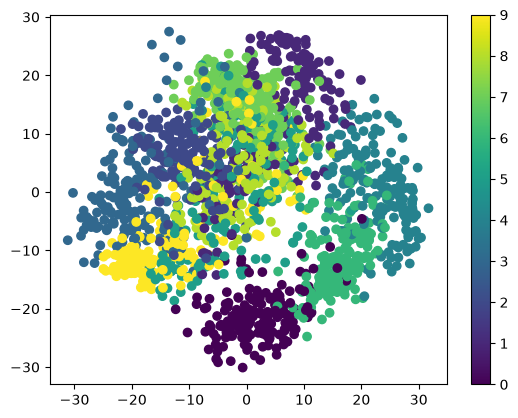

In [27]:
# Build a graphic
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)
plt.colorbar()

Ainsi, on peut voir comment sont organisés/distribués, dans un espace 2D, les échantillons du dataset `digits`.

On remarque que le 0 est placé tout en bas, et le 1 complètement à l'opposé. Ce qui peut se comprendre car les deux chiffres n'ont pas du tout la même forme. 

Pour comprendre à quoi correspondent les axes de ce graphique, il faut analyser le contenu de chaque composante. Cela peut se faire avec `model.components_`

In [28]:
# Extract the containt of each component
print("Components containt:\n", model.components_)
print(f"\nComponents shape: {model.components_.shape}")

Components containt:
 [[ 0.00000000e+00 -1.73094651e-02 -2.23428835e-01 -1.35913304e-01
  -3.30323092e-02 -9.66340844e-02 -8.32943805e-03  2.26900082e-03
  -3.20516495e-04 -1.19308905e-01 -2.44451676e-01  1.48512745e-01
  -4.67319410e-02 -2.17740744e-01 -1.48136776e-02  4.47779518e-03
  -4.94136398e-05 -7.95419375e-02  8.33951454e-02  2.15915342e-01
  -1.72126801e-01 -1.63712098e-01  2.86444452e-02  4.23251803e-03
   9.85488574e-05  6.42319144e-02  2.54093316e-01 -3.56771026e-02
  -2.09462569e-01 -4.31311420e-02  5.13118688e-02  2.13422732e-04
   0.00000000e+00  1.59950883e-01  3.68690774e-01  1.64406827e-01
   8.52007908e-02  3.72982855e-02  2.15866980e-02  0.00000000e+00
   1.28865585e-03  1.06945287e-01  3.03067457e-01  2.47813041e-01
   2.09637296e-01  1.22325219e-02 -3.69458497e-02  1.61485028e-03
   6.93023548e-04 -8.35144239e-03 -5.58598986e-02  9.30534169e-02
   1.07387720e-01 -1.37734565e-01 -6.32879466e-02  9.61671077e-04
   9.55079131e-06 -1.40786840e-02 -2.35675488e-01 -1.4

On voit ici que chacune des deux composantes contiennent 64 valeurs. Pourquoi 64, eh bien parce que chaque composante est une combinaison linéaire de nos 64 variables de notre dataset d'origine. Ainsi, si on examine assez longtemps les 64 valeurs qu'il y a dans chaque composante, on est un peu en mesure de comprendre à quoi correspondent chacun des deux axes. 

À noter que cete exercice est assez abstrait et difficile à faire ! 

Une autre façon d'afficher les données de manière plus intuitives pour des humains peut être de directement montrer les valeurs dans le graphique :

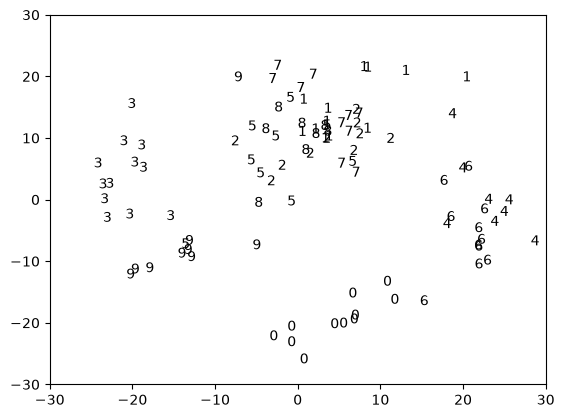

In [34]:
# Build another graph
plt.figure()
plt.xlim(-30, 30)
plt.ylim(-30, 30)

for i in range(100):
    plt.text(X_reduced[i, 0], X_reduced[i, 1], str(y[i]))

<h3><u>PCA pour compresser un dataset</u> :</h3>

Voyons désormais comment utiliser l'algorithme PCA pour compresser un dataset dans le but d'accéléter l'apprentissage d'un modèle. On la mentionné au dessus, le but c'est de préserver entre 95 et 99% de la variance de nos variables d'origines. 

Pour cela, on va commencer à ajuster notre modèle PCA sur le même nombre de dimension qu'on a actuellement dans `X` (dataset `digits` encore). 

In [30]:
# Instantiate the model on the 64
model = PCA(n_components=64)

# Adjust the model on the original 64 dimensions
X_reduced = model.fit_transform(X)

Ensuite, on va examiner quel est le pourcentage de variance préservé par chacune de nos composantes. Pout cela, on va utiliser la méthode `explained_variance_ratio_` 

In [ ]:
# Display the preserved variance ratio
model.explained_variance_ratio_

array([1.48905936e-01, 1.36187712e-01, 1.17945938e-01, 8.40997942e-02,
       5.78241466e-02, 4.91691032e-02, 4.31598701e-02, 3.66137258e-02,
       3.35324810e-02, 3.07880621e-02, 2.37234084e-02, 2.27269657e-02,
       1.82186331e-02, 1.77385494e-02, 1.46710109e-02, 1.40971560e-02,
       1.31858920e-02, 1.24813782e-02, 1.01771796e-02, 9.05617439e-03,
       8.89538461e-03, 7.97123157e-03, 7.67493255e-03, 7.22903569e-03,
       6.95888851e-03, 5.96081458e-03, 5.75614688e-03, 5.15157582e-03,
       4.89539777e-03, 4.28887968e-03, 3.73606048e-03, 3.53274223e-03,
       3.36683986e-03, 3.28029851e-03, 3.08320884e-03, 2.93778629e-03,
       2.56588609e-03, 2.27742397e-03, 2.22277922e-03, 2.11430393e-03,
       1.89909062e-03, 1.58652907e-03, 1.51159934e-03, 1.40578764e-03,
       1.16622290e-03, 1.07492521e-03, 9.64053065e-04, 7.74630271e-04,
       5.57211553e-04, 4.04330693e-04, 2.09916327e-04, 8.24797098e-05,
       5.25149980e-05, 5.05243719e-05, 3.29961363e-05, 1.24365445e-05,
      

Ainsi on obtient le pourcentage de variance préservé pour chacune de nos variables. Une fois qu'on a ces valeurs, on va calculer la somme cumulée de toutes ces variances et chercher dans ces données, l'endroit où on atteint entre 95 ou 99 %. La valeur exacte se choisit de manière arbitraire. C'est à l'utilisateur de choisir en fonction de son besoin et de son cas d'application. Cela dépend également du compromis qu'on cherche à avoir, entre réduire au maximum le dataset et garder un maximum d'informations.

In [32]:
# Compute the cumulated sum of the variance ratios
np.cumsum(model.explained_variance_ratio_)

array([0.14890594, 0.28509365, 0.40303959, 0.48713938, 0.54496353,
       0.59413263, 0.6372925 , 0.67390623, 0.70743871, 0.73822677,
       0.76195018, 0.78467714, 0.80289578, 0.82063433, 0.83530534,
       0.84940249, 0.86258838, 0.87506976, 0.88524694, 0.89430312,
       0.9031985 , 0.91116973, 0.91884467, 0.9260737 , 0.93303259,
       0.9389934 , 0.94474955, 0.94990113, 0.95479652, 0.9590854 ,
       0.96282146, 0.96635421, 0.96972105, 0.97300135, 0.97608455,
       0.97902234, 0.98158823, 0.98386565, 0.98608843, 0.98820273,
       0.99010182, 0.99168835, 0.99319995, 0.99460574, 0.99577196,
       0.99684689, 0.99781094, 0.99858557, 0.99914278, 0.99954711,
       0.99975703, 0.99983951, 0.99989203, 0.99994255, 0.99997555,
       0.99998798, 0.99999503, 0.99999804, 0.99999911, 0.99999966,
       1.        , 1.        , 1.        , 1.        ])

Un manière plus visuelle de choisir une valeur peut également être d'avoir recours à un ghraphique. c'est-à-dire en traçant ces valeurs dans un repère. 

Best dim: 40


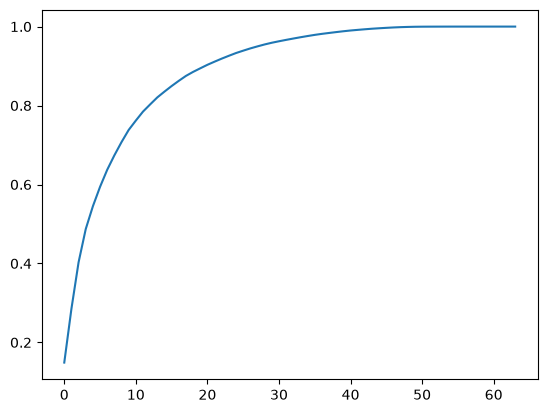

In [37]:
# Plot the cumulative sum variance ratio 
plt.plot(np.cumsum(model.explained_variance_ratio_))

# Extract the number of the Principal component that allow to get 99 % of our model variance
best_dim = np.argmax(np.cumsum(model.explained_variance_ratio_) > 0.99)
# Display the best dim
print("Best dim:", best_dim)

De cette manière, on a pu déterminer la composante principale, à partir de laquelle on atteint 99% de la variance de notre modèle.
En d'autres termes, pour que notre modèle ne soit pas dégradé de plus de 1%, alors il faut projet notre dataset initiale de 64 dimension dans un espace d'au minimum 40 dimension. En dessous, notre dataset sera dégradé de plus de 1% et ne pourra par garantir les 99% de variance des variable de notre dataset initiale.

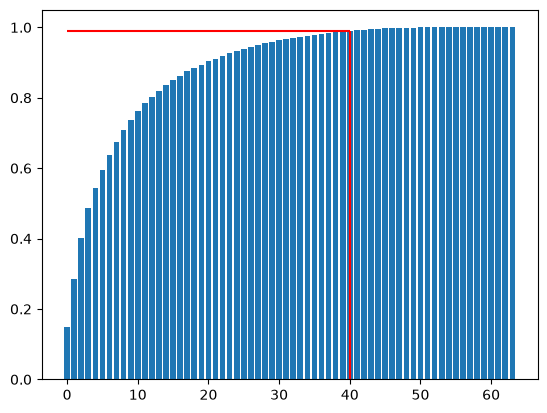

In [40]:
# More accurate displaying
plt.bar(range(64), np.cumsum(model.explained_variance_ratio_))
plt.hlines(0.99, 0, best_dim, color='r')
plt.vlines(best_dim, 0, 0.99, colors='r')

Une fois qu'on a pu déterminer le nombre de dimensions limite de réduction de notre dataset initiale, on va réajuster notre modèle et transformer notre dataset pour que les données soient projeté dans un espace à 40 dimensions : 

In [53]:
# Instantiate our model for 40 dimensions
model = PCA(n_components=40)

# Transforme our dataset reducing its dimensions
X_reduced = model.fit_transform(X)

Ainsi, on a réduit le plus qu'on pouvait notre dataset tout en cnoservant 99% de la variance de nos variables initiales. 

Et pour finir, si on souhaite observer ces images une fois qu'elles ont été compressées, il faut commencer par les décompressées de manière à ce qu'elles aient à nouveau 64 pixels. Pour cela, on peut avoir recour à la méthode `inverse_transformed` de notre model : 

In [54]:
# Decompress data
X_recovered = model.inverse_transform(X_reduced)

# Display data and shape
print(X_recovered)
print(X_recovered.shape)

# Check how many components are used within our model
print(f"Check the number of component used within our model: ", model.n_components_)

[[ 0.00000000e+00 -9.73614086e-03  5.51716653e+00 ... -2.81082899e-01
  -6.07525693e-01  5.04024495e-01]
 [ 0.00000000e+00 -1.52473335e-01  3.62234454e-01 ...  1.04230702e+01
   6.97584185e-02 -5.62597515e-01]
 [ 0.00000000e+00  1.70630202e-01 -4.22889657e-03 ...  1.56135815e+01
   8.48573372e+00  1.21263421e+00]
 ...
 [ 0.00000000e+00 -2.97747947e-01  1.43598331e+00 ...  5.93977009e+00
  -1.88458202e-01 -2.76680024e-01]
 [ 0.00000000e+00 -1.21526640e-01  4.12290711e+00 ...  1.19218425e+01
   5.19131001e-01  1.26522143e-01]
 [ 0.00000000e+00  4.38548545e-01  9.38224996e+00 ...  1.20489957e+01
   1.21760022e+00 -7.37766918e-01]]
(1797, 64)
Check the number of component used within our model:  40


Attention ! Il faut bien comprendre qu'en décompressant nos données, celles-ci ne retrouvent pas exactement l'emplacement qu'elles avaient à l'origine. En effet, l'application de la méthode PCA est destructive. On a supprimer des informations pour pouvoir réduire la taille de nos données, même si on a gardé 99% de notre variance. Par conséquent, ces données supprimées ne peuvent pas être retrouvées. À la place, on repositionne simplement les axes, c'est-à-dire les composantes principales, là où elles ont été calculées dans notre dataset. 

Affichons une de ces images décompressée:

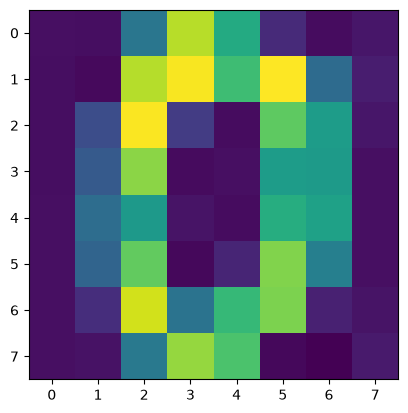

In [46]:
# Displaying the first image reshaping it so that it can be defined as 8x8 pixels height and wide
plt.imshow(X_recovered[0].reshape((8,8)))

Text(0.5, 1.0, 'Compressed')

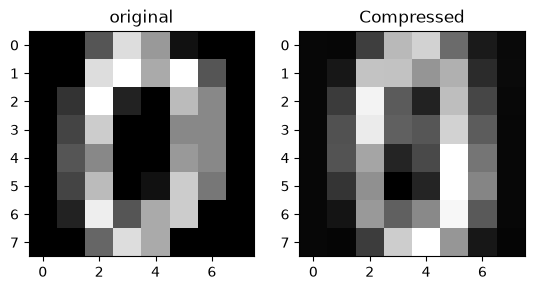

In [51]:
# Compare initial image with compressed image
plt.subplot(1, 2, 1)
plt.imshow(X[0, :].reshape((8,8)), cmap='gray')
plt.title('original')
plt.subplot(1, 2, 2)
plt.imshow(X_recovered[0, :].reshape((8,8)), cmap="gray")
plt.title("Compressed")

Ainsi, on peut voir que la compression en PCA en 40 dimension (au lieu de 64) a préservé beaucoup de la qualité de notre image. Les seuls éléments qui semblent avoir perdu en qualité sont les éléments de l'arrière plan. Ce qui n'est pas vraiment important dans CE cas de figure. En effet, pour reconnaître un chiffre, ce n'est pas l'arrière plan qui compte, mais plutôt la zone centrale.

Ce qui pourrait être intéressant c'est de voir à quel point la qualité peut être affectée en changeant le nombre de composantes principales. 

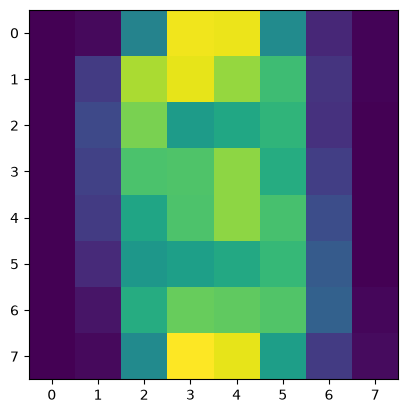

In [47]:
# Instantiate our model for 40 dimensions
model = PCA(n_components=1)

# Transforme our dataset reducing its dimensions
X_reduced = model.fit_transform(X)

# Decompress data
X_recovered = model.inverse_transform(X_reduced)

# Displaying the first image reshaping it so that it can be defined as 8x8 pixels height and wide
plt.imshow(X_recovered[0].reshape((8,8)))

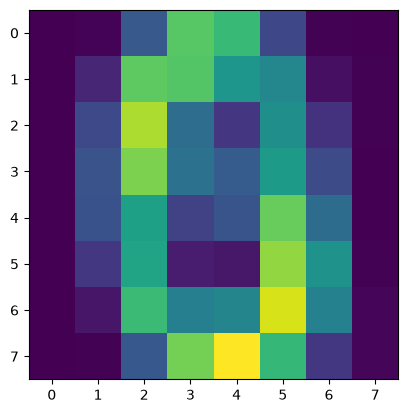

In [48]:
# Instantiate our model for 40 dimensions
model = PCA(n_components=2)

# Transforme our dataset reducing its dimensions
X_reduced = model.fit_transform(X)

# Decompress data
X_recovered = model.inverse_transform(X_reduced)

# Displaying the first image reshaping it so that it can be defined as 8x8 pixels height and wide
plt.imshow(X_recovered[0].reshape((8,8)))

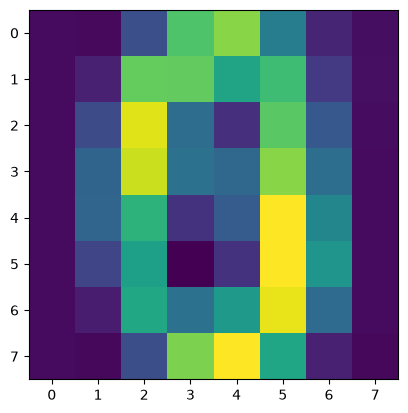

In [49]:
# Instantiate our model for 40 dimensions
model = PCA(n_components=3)

# Transforme our dataset reducing its dimensions
X_reduced = model.fit_transform(X)

# Decompress data
X_recovered = model.inverse_transform(X_reduced)

# Displaying the first image reshaping it so that it can be defined as 8x8 pixels height and wide
plt.imshow(X_recovered[0].reshape((8,8)))

Ainsi, on constate bien que, plus on ajoute de dimensions, plus le pourcentage de la variance qui est préservé augmente.

ASTUCE : pour aller plus vite, quand on utilise le modèle `PCA` de Scikit-learn, on peut directement préciser le pourcentage max de variance préservée qu'on désite avoir : `PCA(n_components=0.95)`. Ainsi, 95% de la variance est préservée. 

Number of component used: 29



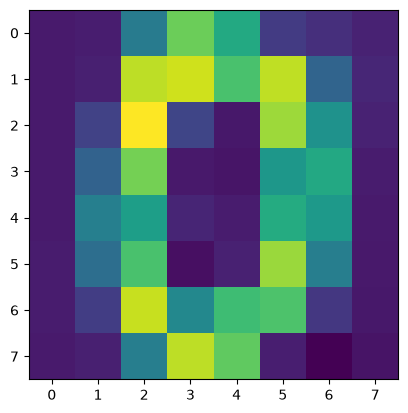

In [56]:
# Instantiate our model for 40 dimensions
model = PCA(n_components=0.95)

# Transforme our dataset reducing its dimensions
X_reduced = model.fit_transform(X)

# Display the number of component used
print(f"Number of component used: {model.n_components_}\n")

# Decompress data
X_recovered = model.inverse_transform(X_reduced)

# Displaying the first image reshaping it so that it can be defined as 8x8 pixels height and wide
plt.imshow(X_recovered[0].reshape((8,8)))

Ici, 29 composantes sont nécessaire pour atteindre 95% de la variances des variables initiales de notre dataset. 

<h3><u>Conclusion PCA</u> :</h3>

Pour conclure avec l'utilisation de cet algorithme, il y a quelques éléments très important à garder en tête afin de bien l'utiliser :
- il faut TOUJOURS standardiser nos données avant de les utiliser dans PCA. Les raisons, sont que les axes d'analyses en composantes principales partent tous de l'origine de nos données. C'est pourquoi il est très important que nos données soient centrées. Il est également nécessaire que nos données aient une variance égale à `1`, ce qui facilite beaucoup la projection de nos données sur ces axes.

- l'algorithme PCA est normalement conçu pour traiter des variables continues. Il arrive que des personnes tentent d'utiliser ce modèle pour projeter des variables, encodées en One-Hot-Encoding, dans des espaces de plus petite dimensions. Cela fonctionne, mais PCA n'est pas conçu pour réaliser ce genre de choses.

- L'analyse en composante principale ne permet pas de projeter efficacement des données dans lesquelles il y a des relations non-linéaires. Dans ces cas de figures, on préfère utiliser des techniques de `Many-Fold Learning`, telles que `IsoMap` ou `T-SNE`. 

Quoi qu'il en soit, PCA est une valeur sûr, très utilisée en Data Science. Il est donc important de le maîtriser et de le rajouter à notre boite à outil.